In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# SEISFWI imports
from seisfwi.model import AcousticModelVAE, AcousticModelSaturation
from seisfwi.propagator import AcousticPropagator
from seisfwi.problem import DeterministicFWI, L2Loss
from seisfwi.utils import smooth2d
from HMC_FWI_VAE import get_survey

from utils.vae import VanillaVAE
from utils import RockPhysicsModel
from utils.project_plots import plot_2d

### Trained VAE Models

In [3]:
path = Path('/net/vision/scr2/haipeng/FWI-HMC/')

# Model
in_channels = 1
latent_dim = 64
kld_weight = 0.000015
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload the model
checkpoint_path = path / f"VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"
vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load(checkpoint_path, map_location=device))
vae.eval()
None

### Load Model and Survey

In [4]:
# Get model, survey and data parameters
f0 = 30
src_id = 2
model_bl, model_ml, survey = get_survey(f0=f0, src_id=src_id)
ox, oz = model_bl.ox, model_bl.oz
nx, nz = model_bl.nx, model_bl.nz
dx, dz = model_bl.dx, model_bl.dz
vp_bl = model_bl.get_model('vp')
vp_ml = model_ml.get_model('vp')
free_surface = model_bl.free_surface

x = np.arange(nx) * dx + ox
z = np.arange(nz) * dz + oz

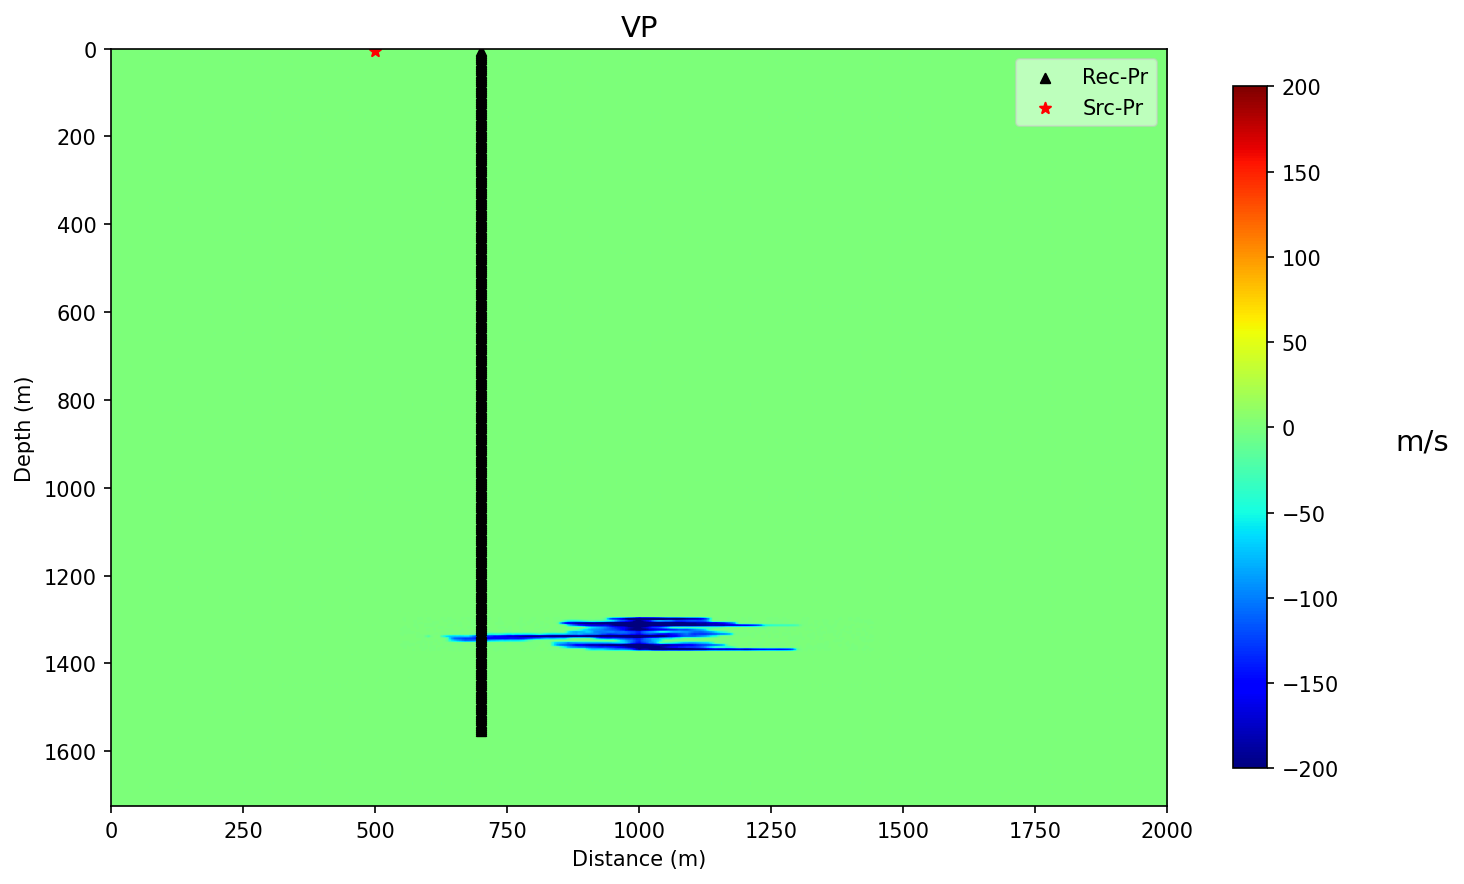

In [5]:
(model_ml - model_bl).plot(survey, cmap_range = {'vp': (-200, 200)})

In [6]:
F = AcousticPropagator(model_bl, survey)
dobs_bl = F(model_bl)
dobs_ml = F(model_ml)

2025-11-22 22:36:19,428 - INFO - Survey analysis completed: all sources and receivers within model range.


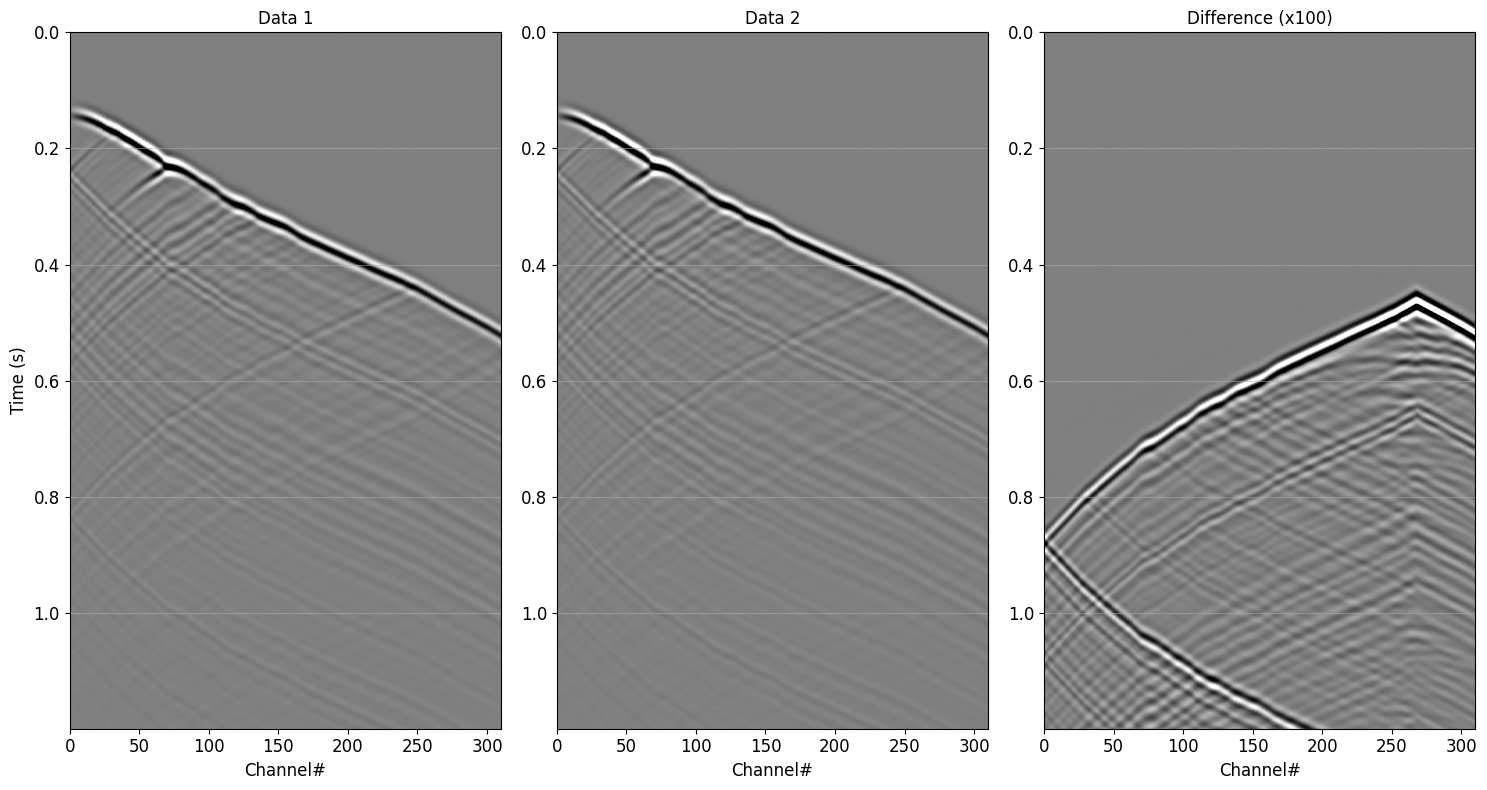

In [7]:
dobs_ml.plot_compare(dobs_bl, comp=['pr'], ratio=100)

### Rock Physics Model

In [8]:
### Roch Physics Model
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 
vp_res = vp_bl[nz0:nz0+nz_res, nx0:nx0+nx_res].copy()

rock_physics_params = RockPhysicsModel(vp_res)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [9]:
# plot_2d(x_res, z_res, vp_res, vmin=2000, vmax=5000, cmap='jet', figsize = (10, 4))

In [10]:
mask_grad = np.ones_like(vp_bl)
mask_grad[:140,:] = 0.0
mask_grad = smooth2d(mask_grad, 5, 5)

In [11]:
model_fwi_vae = AcousticModelVAE(
    ox, oz, dx, dz, nx, nz, 
    vae,
    rock_physics_params,
    vp_bl,
    latent_grad=True,
    latent_bound=[-10, 10],
    mask_grad=mask_grad,
    free_surface=free_surface
)

In [12]:
# set the seed for reproducibility
torch.manual_seed(22)
num_samples = 1
z_fwi = torch.randn(num_samples, vae.latent_dim).to(device)
model_fwi_vae.set_model_vector(z_fwi)

In [13]:
model_fwi_vae

Earth model with parameters ['latent_z']:
  Model latent_z:    -1.98 -     2.09 m/s   , requires_grad = False, constrain bound:   -10.00 -    10.00 m/s   
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =   5.00, dz =   5.00 m
  Model dims: nx =    401, nz =    346    (Total: 138746) 
  Free surface: True with nabc = 20
  Device on cuda with dtype torch.float32

In [14]:
id = 800
path_2D = Path('/net/vision/scr2/haipeng/FWI-HMC/model2D')
po_co2 = np.load(path_2D / f'po_prior_slice64_8002_samples_5m.npy')[id]
sa_co2 = np.load(path_2D / f'sa_prior_time25_slice64_8002_samples_5m.npy')[id]

In [15]:
vp_co2, vs_co2, ro_co2 = model_fwi_vae.RockPhyOp(sa_co2)
vp_co2 = vp_co2.cpu().numpy()

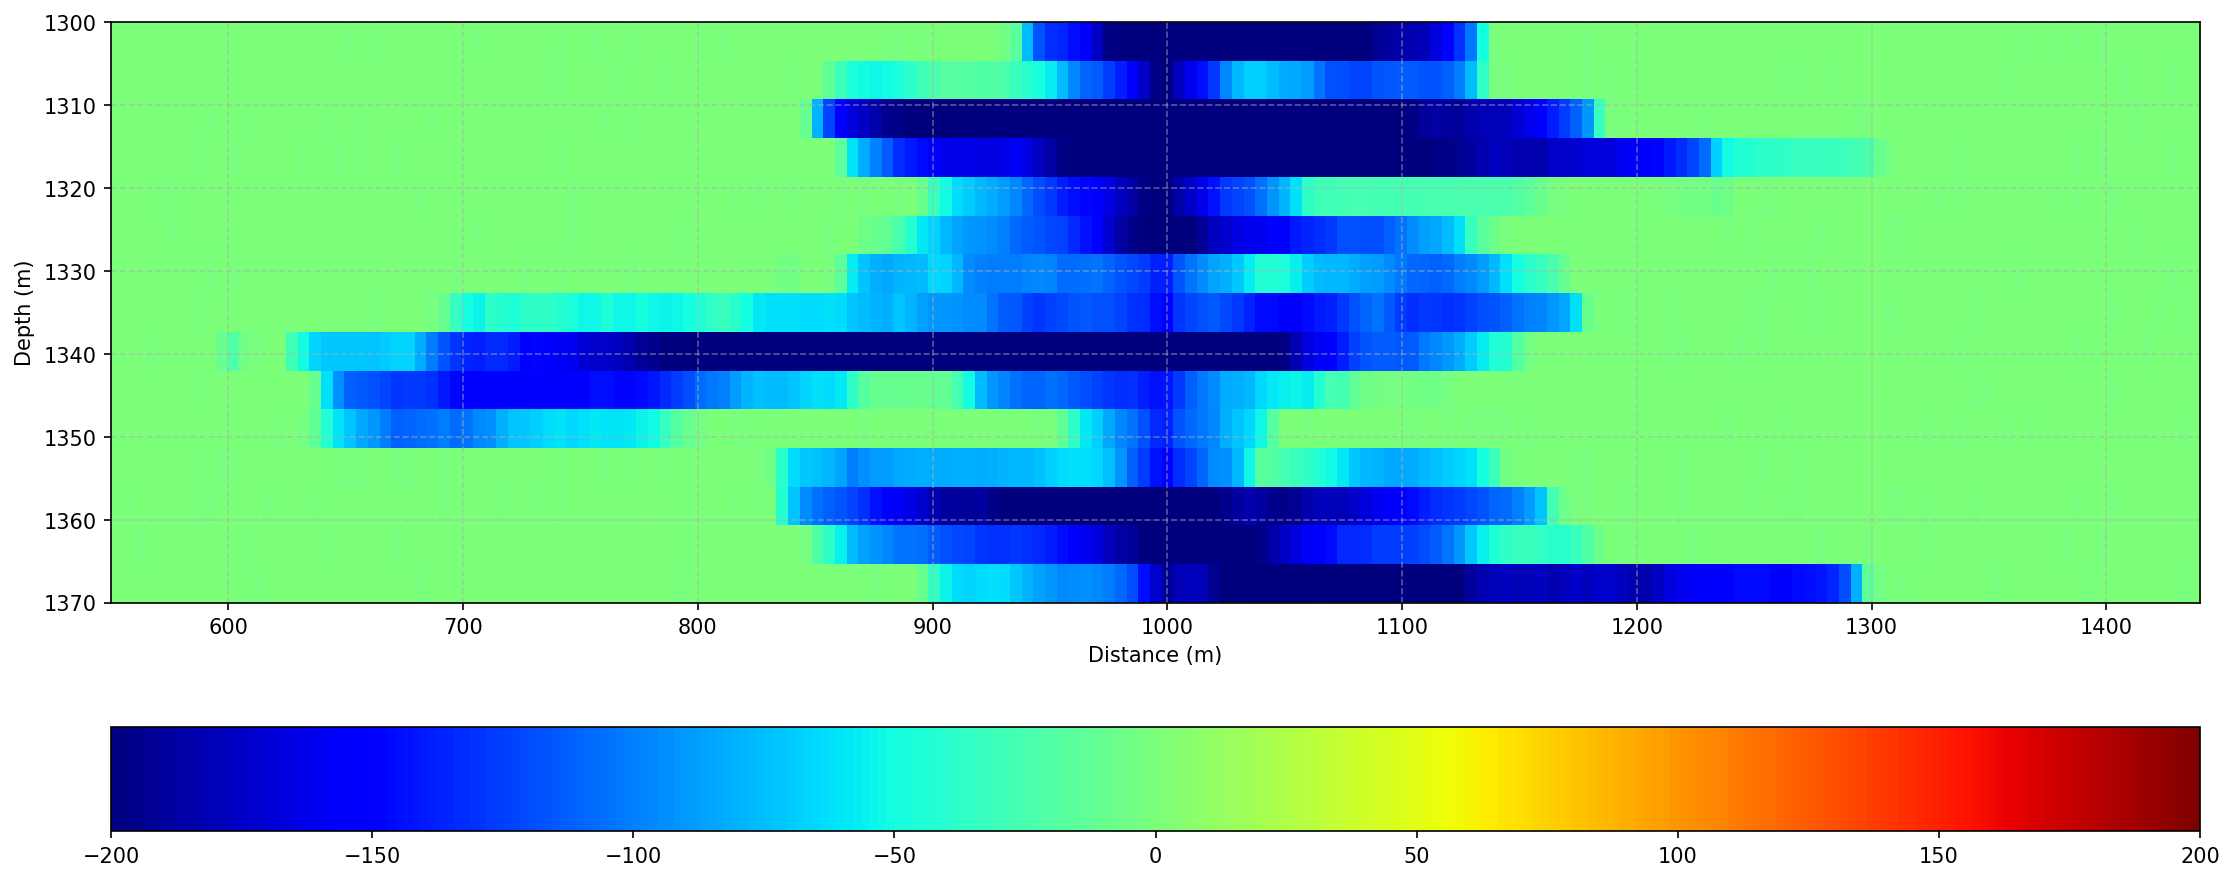

In [16]:
plot_2d(x_res, z_res, vp_co2, vmin=-200, vmax=200, cmap='jet')

In [17]:
model_fwi_vae.latent_z

tensor([[ 0.3920,  0.0734, -0.0045, -0.0535, -0.0589,  0.6002,  2.0421,  1.3273,
         -0.8703, -1.5555, -0.8620, -0.1290,  1.4632,  0.2698, -1.3583, -0.7568,
         -0.4102,  0.2939, -0.0538, -0.9547, -1.3138,  0.4306, -1.3356,  1.1686,
          0.9662, -1.7636, -1.9802, -0.0056,  0.8050,  0.7928, -0.6498,  0.0352,
         -1.1281,  0.8134,  0.2734, -0.3833,  1.1319, -0.1240, -0.6294, -0.5749,
         -0.8881,  0.7359,  0.6198,  0.3908,  1.0492,  0.3543,  0.0289, -1.0003,
         -0.6858,  2.0945,  0.7393, -0.0455, -1.7682, -0.1843, -1.3310,  0.5904,
          0.8605,  0.8002,  1.0861, -0.0626,  1.0136, -0.7909, -0.5482,  1.1483]],
       device='cuda:0')

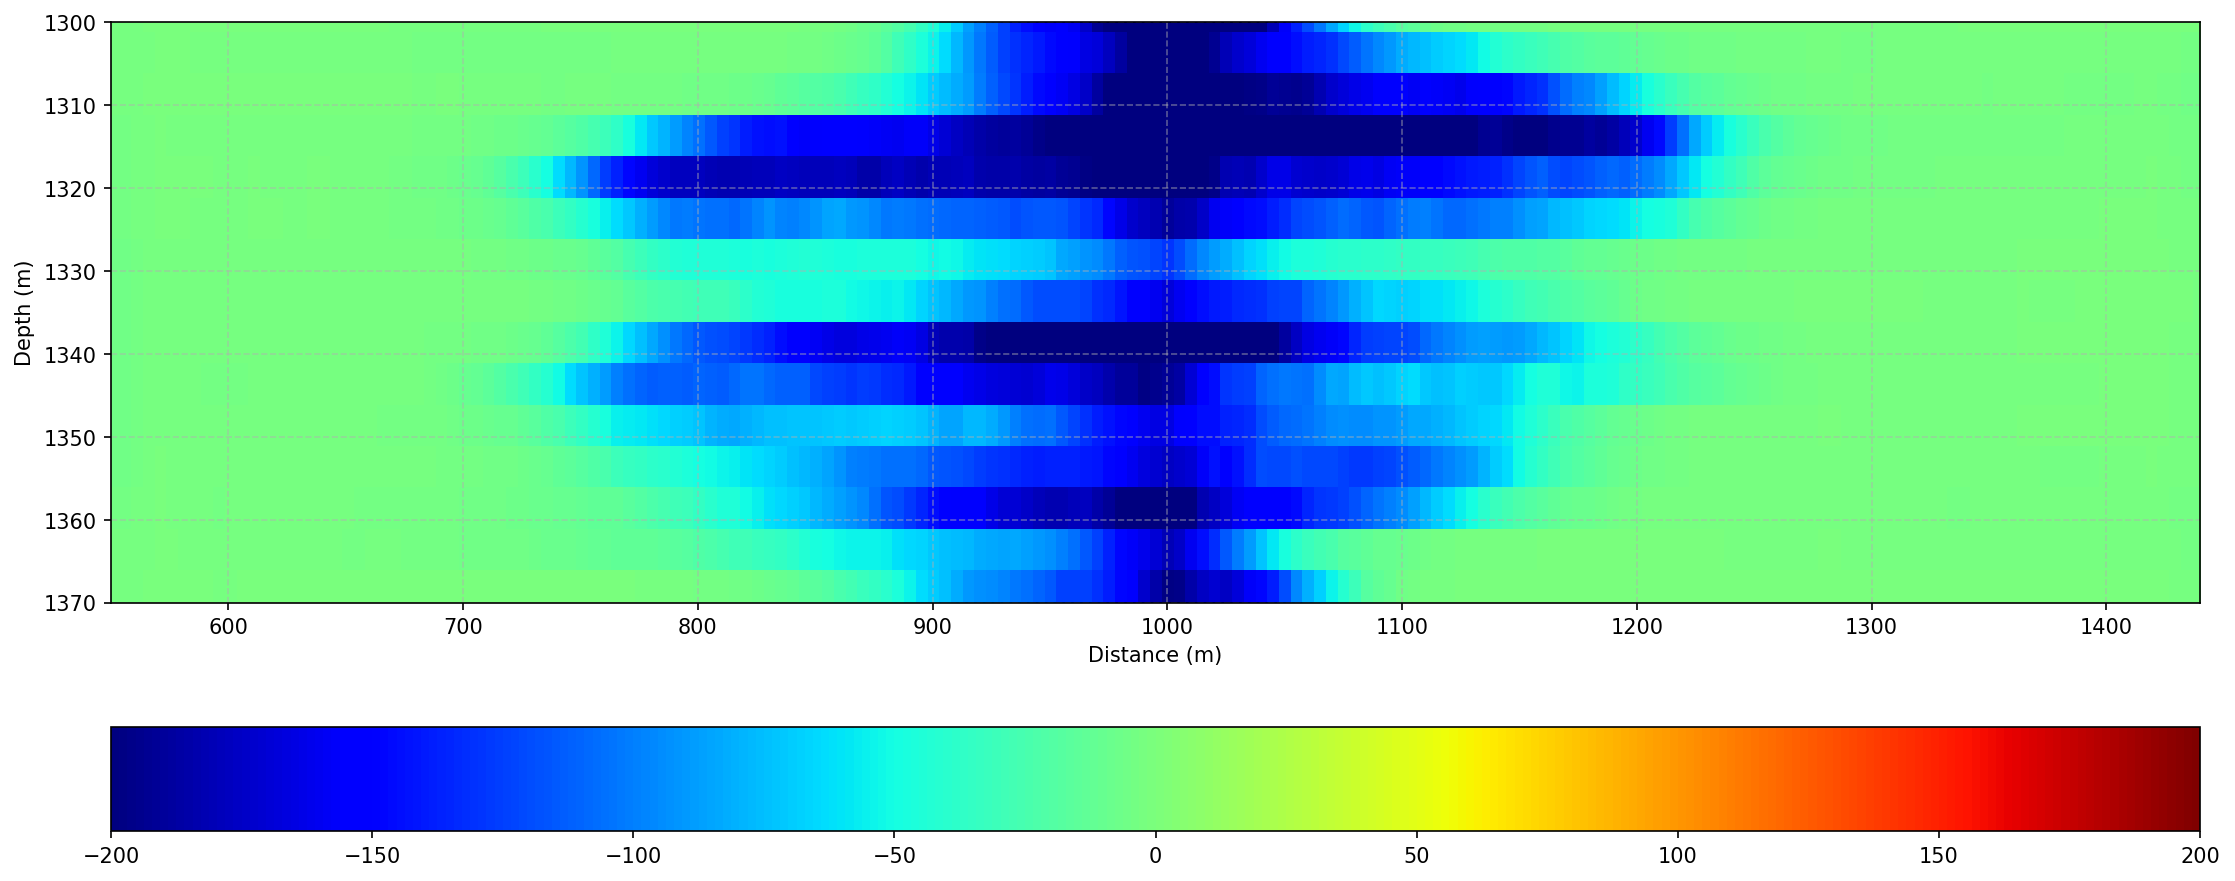

In [18]:
plot_2d(x, z, model_fwi_vae.get_model('vp') - vp_bl, vmin=-200, vmax=200, cmap='jet', xlim=(550,1440), ylim=(1370, 1300))

In [19]:
loss_fn = L2Loss
weight = {'pr': 1.0}
optimizer = "seiscope"
max_iter = 100
grad_scale = 10.0
nshots_per_batch = 4
path_fwi = Path('/net/vision/scr2/haipeng/CO2-Prior/FWI/Deterministic_FWI_VAE/')

In [20]:
fwi = DeterministicFWI(F, model_fwi_vae, loss_fn, dobs_ml, weight)

In [21]:
model_numpy, res = fwi.run(
    optimizer=optimizer,
    max_iter=max_iter,
    grad_scale=grad_scale,
    nshots_per_batch=nshots_per_batch,
    log_file=path_fwi / "FWI.log"
)

2025-11-22 22:36:35,734 - INFO - Starting FWI: optimizer=seiscope, method=LBFGS, max_iter=100


********************************************************************************
             l-BFGS ALGORITHM                
********************************************************************************
     Convergence criterion  : 1.0000e-04
     Niter_max              :        100
     Initial cost is        : 6.4546e+01
     Initial norm_grad is   : 1.0000e+01
********************************************************************************
   Niter      fk         ||gk||       fk/f0        alpha        nls      ngrad   

     1   6.4546e+01   1.0000e+01     1.00e+00     1.00e+00        0        0
     2   6.3507e+01   7.9472e+00     9.84e-01     5.00e-01        1        2
     3   3.3902e+01   6.6374e+00     5.25e-01     5.00e-01        0        3
     4   9.0934e+00   1.5821e+00     1.41e-01     2.50e-01        1        5
     5   8.7376e+00   1.1278e+00     1.35e-01     2.50e-01        0        6
     6   8.2870e+00   7.8214e-01     1.28e-01     2.50e-01        0        7
  

2025-11-22 22:36:53,167 - INFO - FWI optimization completed.


   101   1.1733e+00   4.9066e-02     1.82e-02     5.00e-01        0      111
********************************************************************************
  STOP: MAXIMUM NUMBER OF ITERATION REACHED    
********************************************************************************



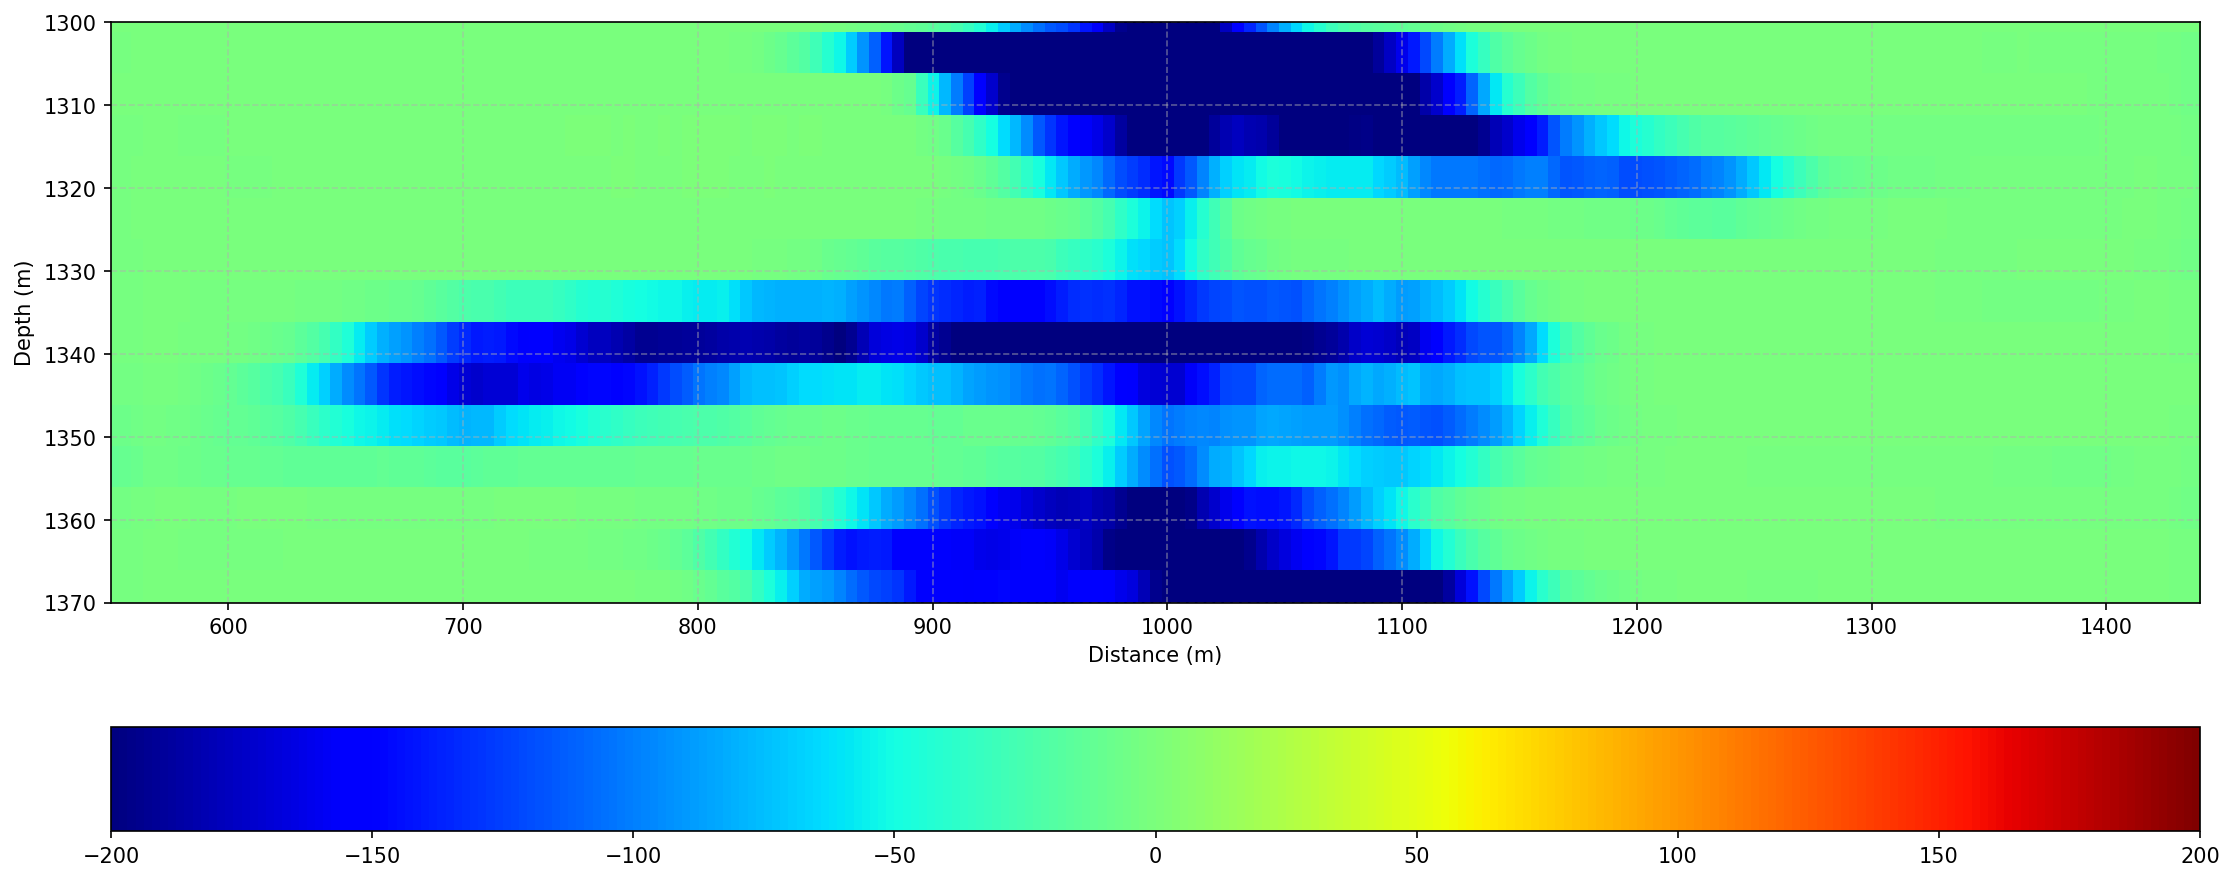

In [22]:
plot_2d(x, z, model_fwi_vae.get_model('vp') - vp_bl, vmin=-200, vmax=200, cmap='jet', xlim=(550,1440), ylim=(1370, 1300))

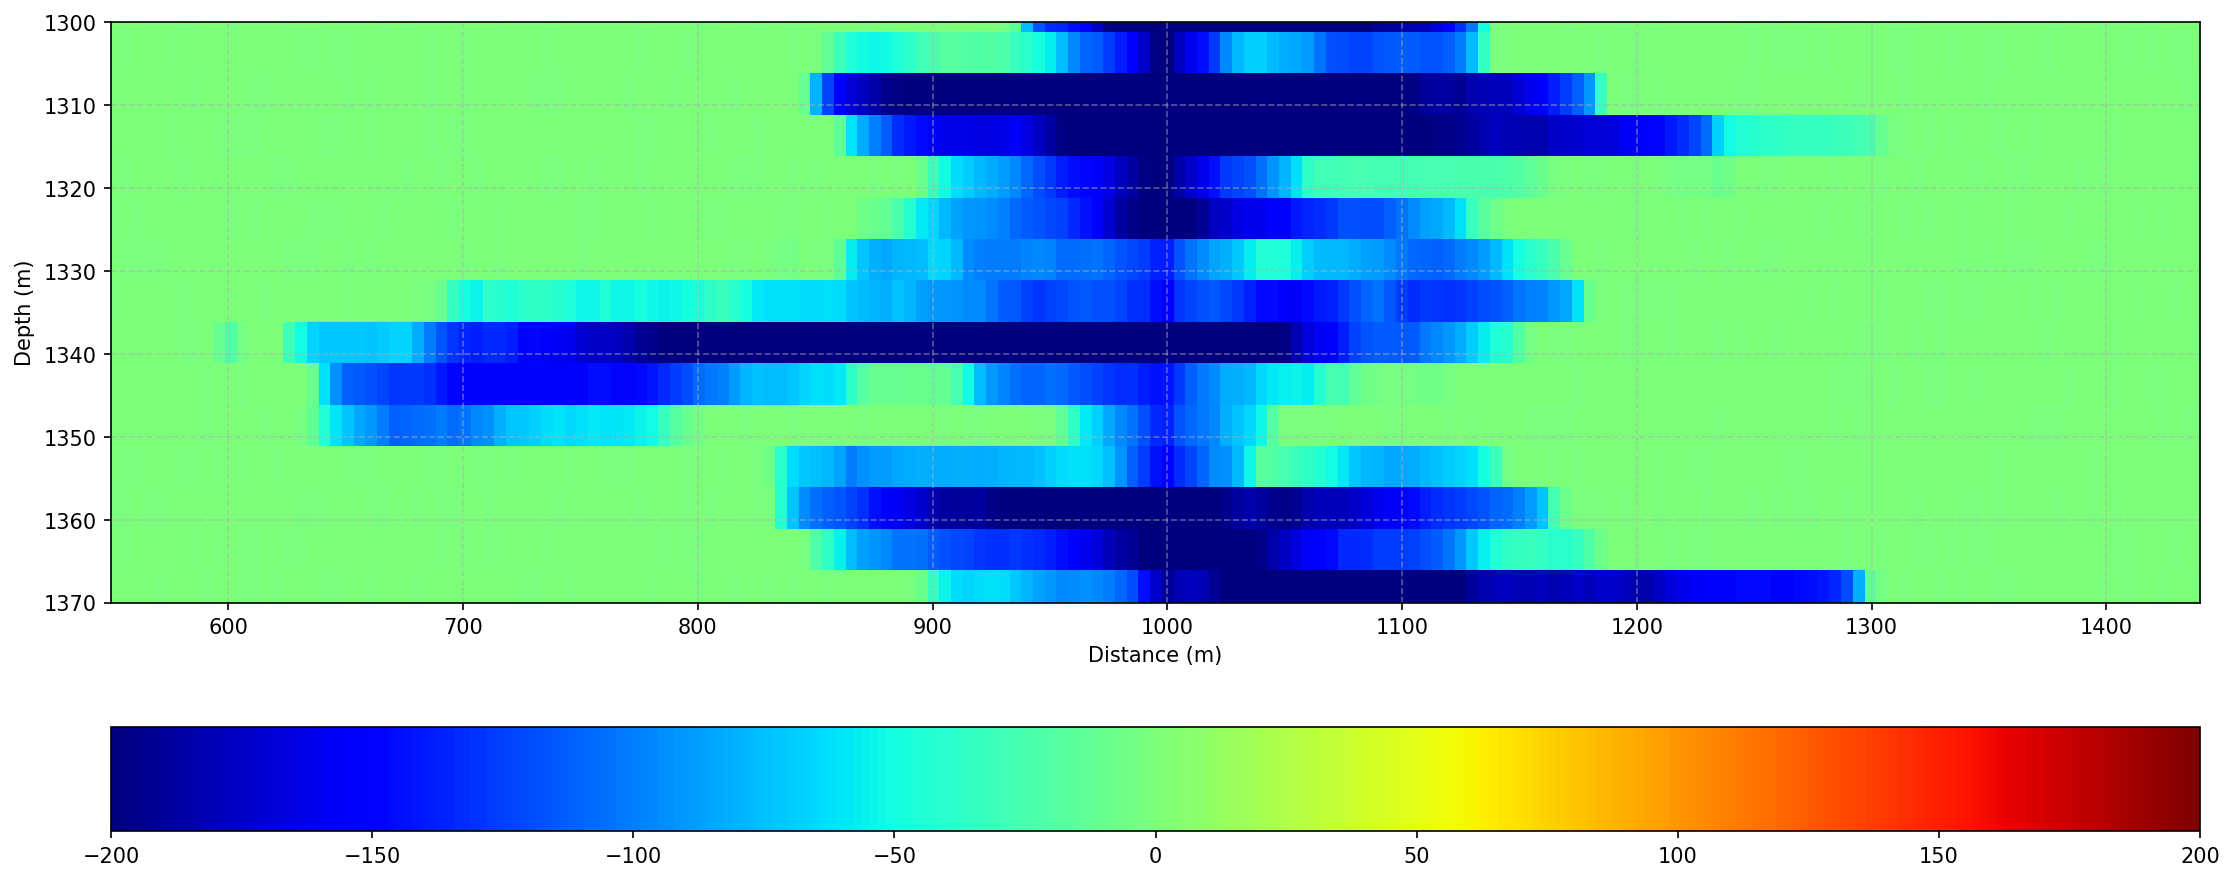

In [23]:
plot_2d(x, z, vp_ml - vp_bl, vmin=-200, vmax=200, cmap='jet', xlim=(550,1440), ylim=(1370, 1300))

In [24]:
# fwi_model = res['model']
# for i in range(fwi_model.shape[0]):
#     fwi_z = torch.tensor(fwi_model[i]).float().to(device)
#     model_fwi_vae.set_model_vector(fwi_z)
#     plot_2d(x, z, model_fwi_vae.get_model('vp') - vp_bl, vmin=-160, vmax=160, cmap='jet', xlim=(550,1440), ylim=(1370, 1300))

In [25]:
fwi_model = res['model']
fwi_model.shape[0]

112

In [26]:
model_numpy

array([ 1.3217862 ,  3.5265863 ,  2.5591967 , -0.18683012, -0.82988083,
       -0.08304732,  1.648824  , -1.6909825 ,  1.4347514 , -8.345129  ,
        1.3197756 ,  0.20185584, -1.169281  ,  0.14379604, -1.9676511 ,
        0.792882  ,  0.75386226,  0.5256499 , -1.5048491 ,  1.1279219 ,
       -3.212847  , -7.0443187 ,  0.09800474,  1.54629   ,  0.2969889 ,
       -0.8241175 , -3.1217813 ,  2.4528515 ,  2.4340177 , -2.2708795 ,
       -0.19322571,  1.2636281 , -1.2871126 ,  4.2005353 , -0.23905867,
        5.11154   ,  5.313135  ,  1.3953109 , -0.9407024 , -2.2322378 ,
        0.5476579 ,  2.1711206 , -5.614594  ,  1.4341449 ,  1.9568235 ,
       -2.2153695 , -1.5421958 ,  2.980768  , -2.0135863 , -4.47364   ,
       -6.1051874 ,  4.540931  , -2.2249966 , -1.506346  ,  1.643051  ,
        0.28017217,  1.7266703 ,  4.2675695 ,  0.7093847 , -2.0223007 ,
       -0.44977272,  1.4677566 , -2.8467598 ,  0.13039343], dtype=float32)

In [27]:
sa_co2_fwi = model_fwi_vae.VAE.decode(torch.tensor(model_numpy, dtype=torch.float32).to(device))
sa_co2_fwi = torch.nn.functional.interpolate(sa_co2_fwi, size=(15, 179), mode='bilinear', align_corners=False).detach().cpu().numpy().squeeze()

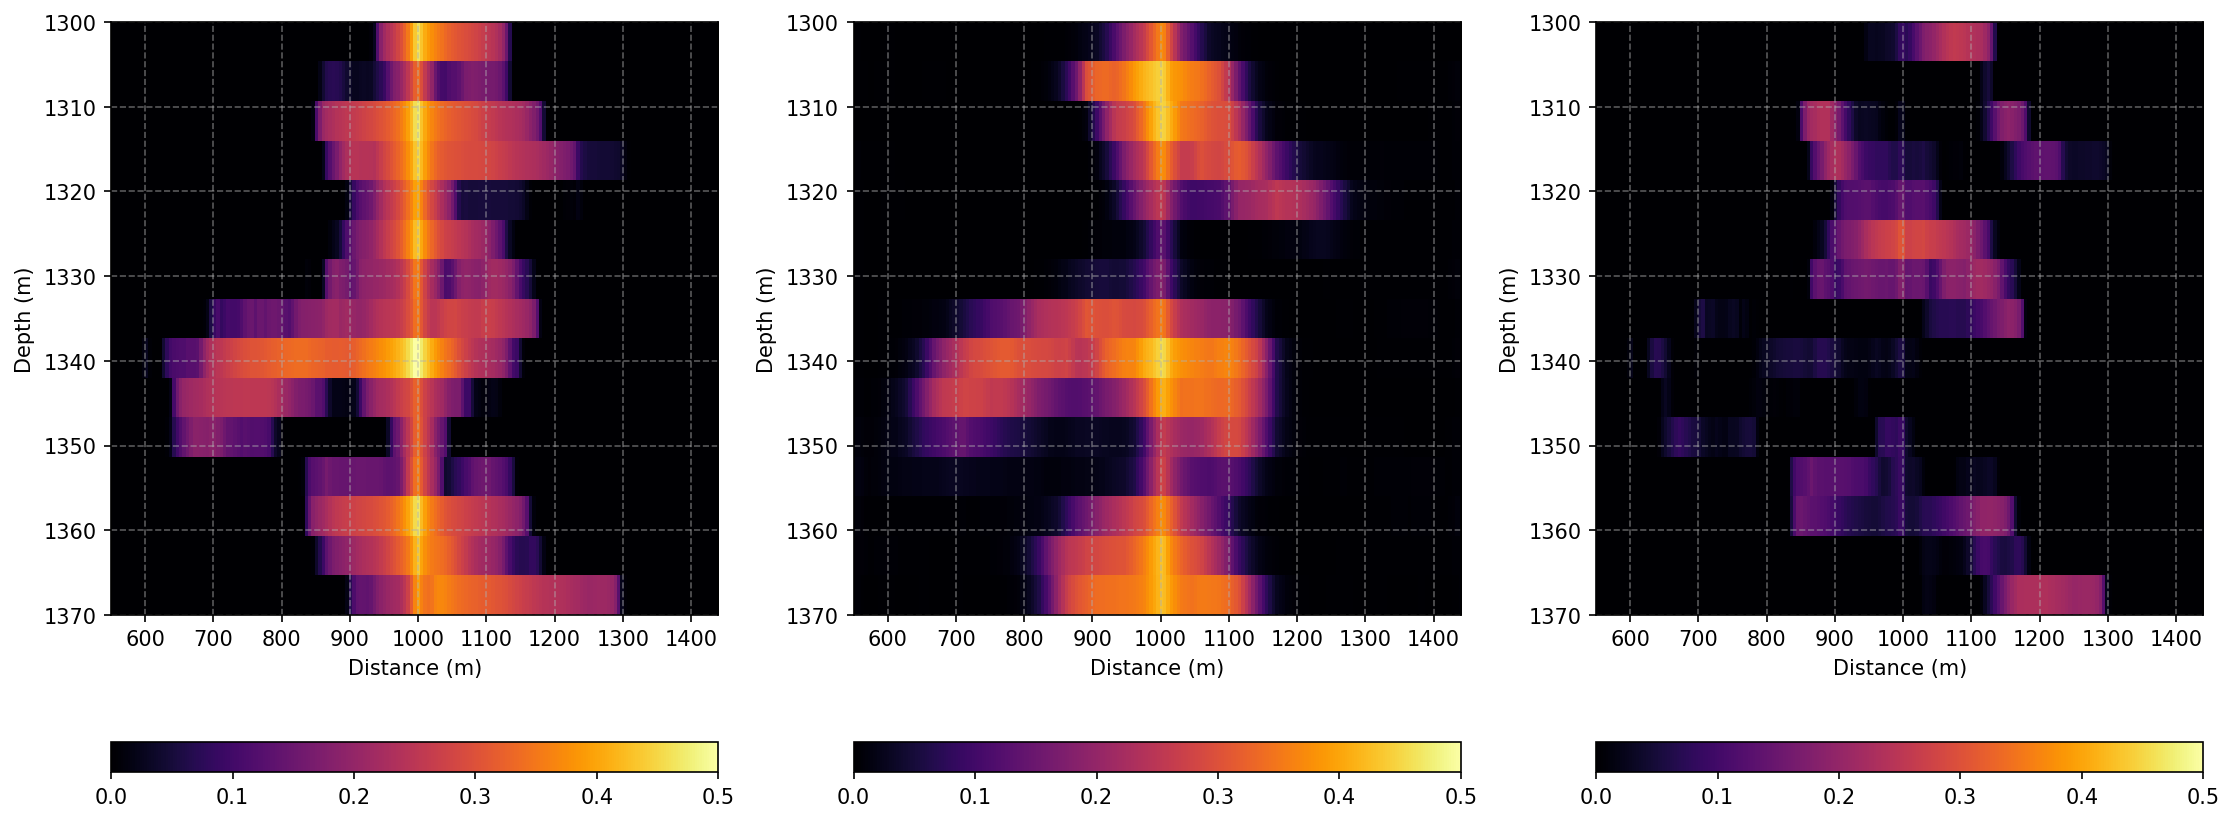

In [28]:
plot_2d(x_res, z_res, [sa_co2, sa_co2_fwi, sa_co2 - sa_co2_fwi], vmin=0, vmax=0.5, cmap='inferno')

### Saturation Model

In [29]:
sa_int = np.zeros_like(sa_co2)
sa_int

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [30]:
model_fwi_sat = AcousticModelSaturation(
    ox, oz, dx, dz, nx, nz, 
    rock_physics_params,
    vp_bl,
    sat = sa_int,
    sat_grad=True,
    sat_bound=[0, 1],
    mask_grad=mask_grad,
    free_surface=free_surface)


In [31]:
fwi2 = DeterministicFWI(F, model_fwi_sat, loss_fn, dobs_ml, weight)

In [32]:
model_numpy2, res2 = fwi2.run(
    optimizer=optimizer,
    max_iter=max_iter,
    grad_scale=grad_scale,
    nshots_per_batch=nshots_per_batch,
    log_file=path_fwi / "FWI.log"
)

2025-11-22 22:37:07,290 - INFO - Starting FWI: optimizer=seiscope, method=LBFGS, max_iter=100


********************************************************************************
             l-BFGS ALGORITHM                
********************************************************************************
     Convergence criterion  : 1.0000e-04
     Niter_max              :        100
     Initial cost is        : 5.1014e+01
     Initial norm_grad is   : 1.0000e+01
********************************************************************************
   Niter      fk         ||gk||       fk/f0        alpha        nls      ngrad   

     1   5.1014e+01   1.0000e+01     1.00e+00     1.00e+00        0        0
     2   4.9273e+01   9.9815e+00     9.66e-01     3.12e-02        5        6
     3   3.9769e+01   8.7990e+00     7.80e-01     1.25e-01        2        9
     4   3.2389e+01   7.7860e+00     6.35e-01     1.25e-01        0       10
     5   2.6378e+01   6.8715e+00     5.17e-01     1.25e-01        0       11
     6   2.1569e+01   6.0526e+00     4.23e-01     1.25e-01        0       12
  

2025-11-22 22:37:24,104 - INFO - FWI optimization completed.


   100   2.1892e-02   3.3765e-02     4.29e-04     5.00e-01        0      108
   101   2.1467e-02   3.3449e-02     4.21e-04     5.00e-01        0      109
********************************************************************************
  STOP: MAXIMUM NUMBER OF ITERATION REACHED    
********************************************************************************



In [33]:
sa_co2_fwi_new = model_numpy2.reshape(15, 179)

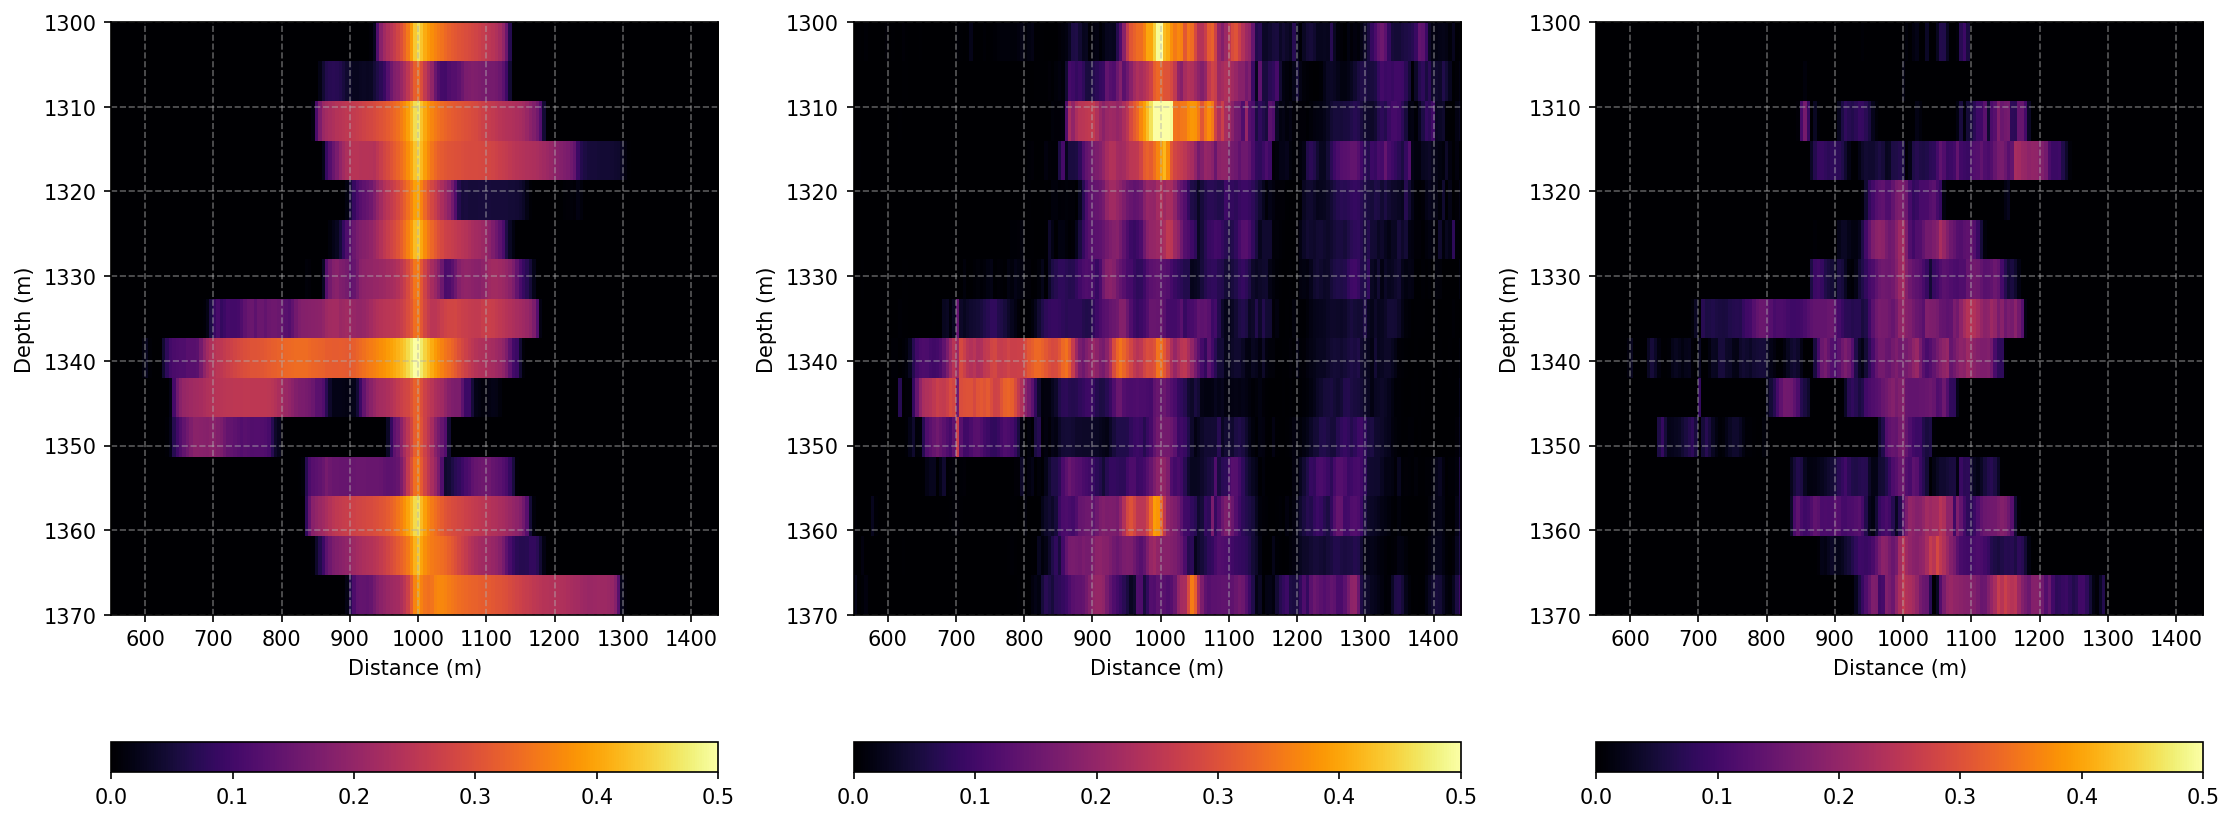

In [34]:
plot_2d(x_res, z_res, [sa_co2, sa_co2_fwi_new, sa_co2 - sa_co2_fwi_new], vmin=0, vmax=0.5, cmap='inferno')